In [1]:
import os
import mlflow
import numpy as np
import pandas as pd
from dotenv import load_dotenv

load_dotenv("/Users/azeemkhalipha/mlops-retail-platform/.env")

PROJECT_ROOT  = os.getenv("PROJECT_ROOT")
FEATURES_PATH = f"{PROJECT_ROOT}/data/features"
MLFLOW_PATH   = f"file://{PROJECT_ROOT}/mlruns"

# Tell MLflow where to store experiments — locally in your project
mlflow.set_tracking_uri(MLFLOW_PATH)

# Create or connect to your experiment
# All runs go under this experiment name
mlflow.set_experiment("demand_forecasting")

print(f"Project root: {PROJECT_ROOT}")
print(f"MLflow path:  {PROJECT_ROOT}/mlruns")
print("MLflow ready")

/Users/azeemkhalipha/anaconda3/envs/mlops/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/06/07 21:59:50 INFO mlflow.tracking.fluent: Experiment with name 'demand_forecasting' does not exist. Creating a new experiment.


Project root: /Users/azeemkhalipha/mlops-retail-platform
MLflow path:  /Users/azeemkhalipha/mlops-retail-platform/mlruns
MLflow ready


In [2]:
# Log a test run to verify MLflow is working
with mlflow.start_run(run_name="test_run"):
    mlflow.log_param("test_param", "hello_mlflow")
    mlflow.log_metric("test_metric", 0.99)
    print("Test run logged successfully")

print("\nMLflow is working correctly")

Test run logged successfully

MLflow is working correctly


In [3]:
# Load the Parquet features you saved in Week 1
df = pd.read_parquet(f"{FEATURES_PATH}/ml_features")

print(f"Feature dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nSample data:")
print(df.head(3))
print(f"\nData types:")
print(df.dtypes)

Feature dataset shape: (330546, 11)

Columns: ['StockCode', 'invoice_date', 'daily_qty', 'daily_revenue', 'daily_orders', 'qty_lag_1', 'qty_lag_7', 'qty_lag_30', 'qty_rolling_avg_7', 'qty_rolling_avg_30', 'qty_rolling_std_7']

Sample data:
  StockCode invoice_date  daily_qty  daily_revenue  daily_orders  qty_lag_1  \
0    10123C   2010-09-27        144           8.64             1         12   
1    10123C   2010-10-03          1           0.65             1        144   
2    10123C   2010-10-11          2           1.30             1          1   

   qty_lag_7  qty_lag_30  qty_rolling_avg_7  qty_rolling_avg_30  \
0        144           1              28.43               15.17   
1          2           2              28.43               19.93   
2          5          10              28.29               19.90   

   qty_rolling_std_7  
0              51.13  
1              51.13  
2              51.21  

Data types:
StockCode              object
invoice_date           object
daily_qty

In [4]:
# These are the 7 features the model will learn from
FEATURE_COLS = [
    "qty_lag_1",          # quantity sold 1 day ago
    "qty_lag_7",          # quantity sold 7 days ago
    "qty_lag_30",         # quantity sold 30 days ago
    "qty_rolling_avg_7",  # 7-day rolling average
    "qty_rolling_avg_30", # 30-day rolling average
    "qty_rolling_std_7",  # 7-day rolling std deviation
    "daily_revenue"       # revenue on that day
]

# Target: what we're trying to predict
# We shift daily_qty by -1 to get "next day's quantity"
# So for each row, the target is: what will be sold TOMORROW?
df = df.sort_values(["StockCode", "invoice_date"])
df["target"] = df.groupby("StockCode")["daily_qty"].shift(-1)

# Remove rows where target is null (last day of each product has no tomorrow)
df = df.dropna(subset=["target"] + FEATURE_COLS)

X = df[FEATURE_COLS]
y = df["target"]

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")
print(f"\nTarget stats:")
print(y.describe())

Features shape: (327619, 7)
Target shape:   (327619,)

Target stats:
count    327619.000000
mean         24.438119
std          81.867953
min           1.000000
25%           3.000000
50%          10.000000
75%          24.000000
max       11124.000000
Name: target, dtype: float64


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for testing, 80% for training
    random_state=42   # Fixed seed so results are reproducible
)

print(f"Train size: {X_train.shape[0]:,} rows")
print(f"Test size:  {X_test.shape[0]:,} rows")

Train size: 262,095 rows
Test size:  65,524 rows


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, model_name):
    """
    Takes a trained model, makes predictions on test set,
    and returns MAE, RMSE, R2 metrics.

    MAE  = Mean Absolute Error (average prediction error in units)
    RMSE = Root Mean Squared Error (penalises large errors more)
    R2   = R-squared (1.0 = perfect, 0.0 = as good as predicting the mean)
    """
    predictions = model.predict(X_test)

    mae  = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)

    print(f"\n{model_name} Results:")
    print(f"  MAE:  {mae:.4f}  (avg error of {mae:.1f} units per prediction)")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R2:   {r2:.4f}  (model explains {r2*100:.1f}% of variance)")

    return {
        "mae":         mae,
        "rmse":        rmse,
        "r2":          r2,
        "predictions": predictions
    }

In [10]:
from sklearn.linear_model import LinearRegression

with mlflow.start_run(run_name="linear_regression"):
    model = LinearRegression()
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test, "Linear Regression")

    mlflow.log_param("model_type", "LinearRegression")
    mlflow.log_param("train_size", len(X_train))
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.sklearn.log_model(model, "model")

2026/06/07 22:19:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:19:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Linear Regression Results:
  MAE:  21.1685  (avg error of 21.2 units per prediction)
  RMSE: 70.0063
  R2:   0.1082  (model explains 10.8% of variance)


In [11]:
from sklearn.linear_model import Ridge

with mlflow.start_run(run_name="ridge_regression"):
    params = {
        "alpha": 1.0  # regularisation strength — higher = more penalty on large weights
    }
    model = Ridge(**params)
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test, "Ridge Regression")

    mlflow.log_params(params)
    mlflow.log_param("model_type", "Ridge")
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.sklearn.log_model(model, "model")

2026/06/07 22:20:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:20:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Ridge Regression Results:
  MAE:  21.1685  (avg error of 21.2 units per prediction)
  RMSE: 70.0063
  R2:   0.1082  (model explains 10.8% of variance)


In [12]:
from sklearn.linear_model import Lasso

with mlflow.start_run(run_name="lasso_regression"):
    params = {
        "alpha": 0.1  # lower alpha than Ridge because Lasso is more aggressive
    }
    model = Lasso(**params)
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test, "Lasso Regression")

    # Show which features Lasso kept vs zeroed out
    feature_weights = dict(zip(FEATURE_COLS, model.coef_))
    print("\nLasso feature coefficients (0 = feature eliminated):")
    for feat, coef in feature_weights.items():
        status = "KEPT" if abs(coef) > 0 else "ELIMINATED"
        print(f"  {feat:25s}: {coef:8.4f} ({status})")

    mlflow.log_params(params)
    mlflow.log_param("model_type", "Lasso")
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.sklearn.log_model(model, "model")

2026/06/07 22:20:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:20:23 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Lasso Regression Results:
  MAE:  21.1687  (avg error of 21.2 units per prediction)
  RMSE: 70.0065
  R2:   0.1082  (model explains 10.8% of variance)

Lasso feature coefficients (0 = feature eliminated):
  qty_lag_1                :  -0.0058 (KEPT)
  qty_lag_7                :  -0.0094 (KEPT)
  qty_lag_30               :  -0.0206 (KEPT)
  qty_rolling_avg_7        :   0.4908 (KEPT)
  qty_rolling_avg_30       :   0.6526 (KEPT)
  qty_rolling_std_7        :  -0.2465 (KEPT)
  daily_revenue            :   0.0113 (KEPT)


2026/06/07 22:20:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:20:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random Forest Results:
  MAE:  21.5060  (avg error of 21.5 units per prediction)
  RMSE: 73.3829
  R2:   0.0201  (model explains 2.0% of variance)


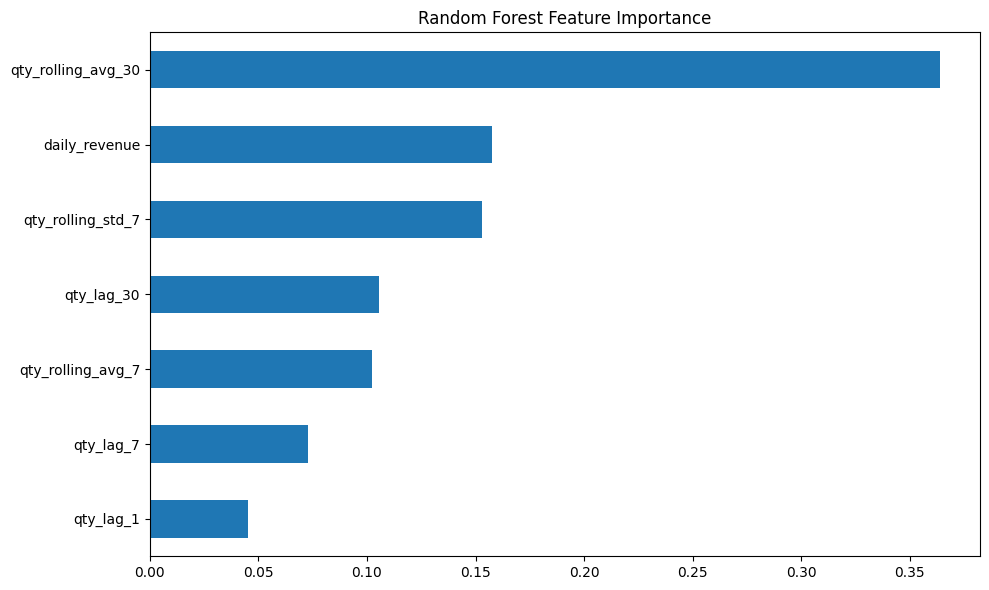

In [13]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

with mlflow.start_run(run_name="random_forest"):
    params = {
        "n_estimators": 100,   # number of trees
        "max_depth":    10,    # max depth of each tree
        "random_state": 42,
        "n_jobs":       -1     # use all CPU cores
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test, "Random Forest")

    mlflow.log_params(params)
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.sklearn.log_model(model, "model")

    # Feature importance plot
    fig, ax = plt.subplots(figsize=(10, 6))
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    importances.sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Random Forest Feature Importance")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")
    plt.show()

In [14]:
from sklearn.ensemble import GradientBoostingRegressor

with mlflow.start_run(run_name="gradient_boosting"):
    params = {
        "n_estimators":  200,
        "max_depth":     4,
        "learning_rate": 0.1,
        "subsample":     0.8,
        "random_state":  42
    }
    model = GradientBoostingRegressor(**params)
    model.fit(X_train, y_train)
    metrics = evaluate_model(model, X_test, y_test, "Gradient Boosting")

    mlflow.log_params(params)
    mlflow.log_param("model_type", "GradientBoosting")
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.sklearn.log_model(model, "model")

2026/06/07 22:22:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:22:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Gradient Boosting Results:
  MAE:  21.3794  (avg error of 21.4 units per prediction)
  RMSE: 73.3317
  R2:   0.0215  (model explains 2.1% of variance)


2026/06/07 22:22:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost Results:
  MAE:  21.5715  (avg error of 21.6 units per prediction)
  RMSE: 74.0163
  R2:   0.0031  (model explains 0.3% of variance)


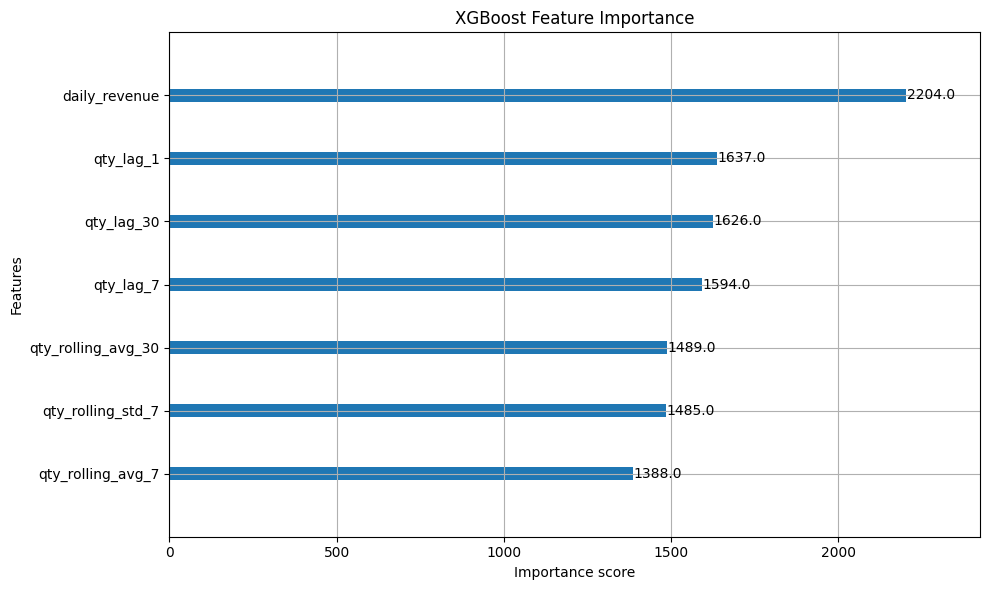

In [15]:
import xgboost as xgb

with mlflow.start_run(run_name="xgboost"):
    params = {
        "n_estimators":     200,
        "max_depth":        6,
        "learning_rate":    0.1,
        "subsample":        0.8,
        "colsample_bytree": 0.8,
        "random_state":     42
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    metrics = evaluate_model(model, X_test, y_test, "XGBoost")

    mlflow.log_params(params)
    mlflow.log_param("model_type", "XGBoost")
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.xgboost.log_model(model, "model")

    fig, ax = plt.subplots(figsize=(10, 6))
    xgb.plot_importance(model, ax=ax, max_num_features=10)
    plt.title("XGBoost Feature Importance")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")
    plt.show()

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1785
[LightGBM] [Info] Number of data points in the train set: 262095, number of used features: 7
[LightGBM] [Info] Start training from score 24.470020
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

2026/06/07 22:26:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:26:28 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



LightGBM Results:
  MAE:  21.2948  (avg error of 21.3 units per prediction)
  RMSE: 70.9473
  R2:   0.0841  (model explains 8.4% of variance)


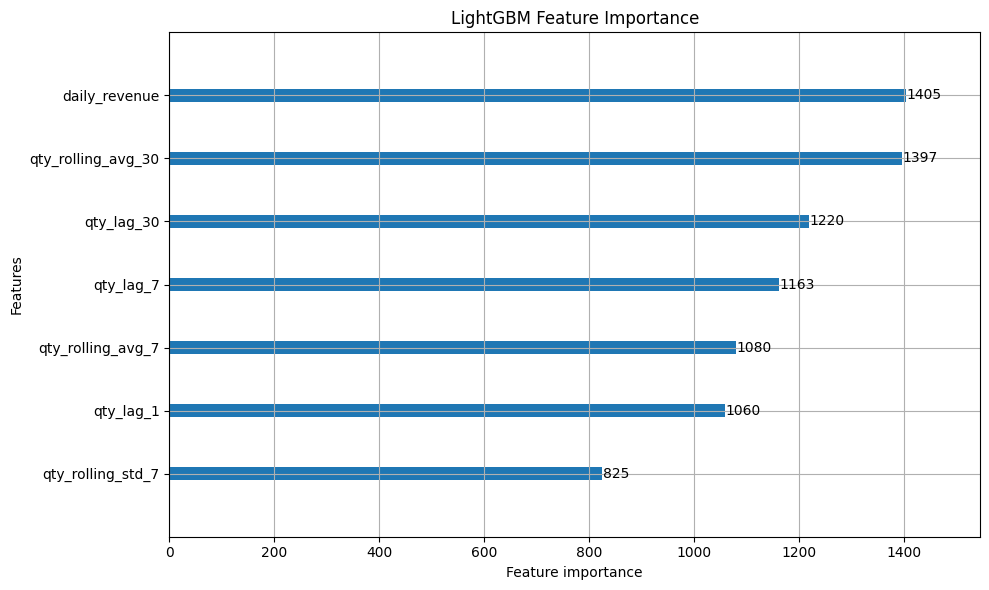

In [16]:
import lightgbm as lgb

with mlflow.start_run(run_name="lightgbm"):
    params = {
        "n_estimators":  300,
        "max_depth":     6,
        "learning_rate": 0.05,
        "num_leaves":    31,
        "subsample":     0.8,
        "random_state":  42
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
    metrics = evaluate_model(model, X_test, y_test, "LightGBM")

    mlflow.log_params(params)
    mlflow.log_param("model_type", "LightGBM")
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.lightgbm.log_model(model, "model")

    fig, ax = plt.subplots(figsize=(10, 6))
    lgb.plot_importance(model, ax=ax, max_num_features=10)
    plt.title("LightGBM Feature Importance")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")
    plt.show()

2026/06/07 22:26:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/07 22:26:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



CatBoost Results:
  MAE:  21.1793  (avg error of 21.2 units per prediction)
  RMSE: 69.9930
  R2:   0.1086  (model explains 10.9% of variance)


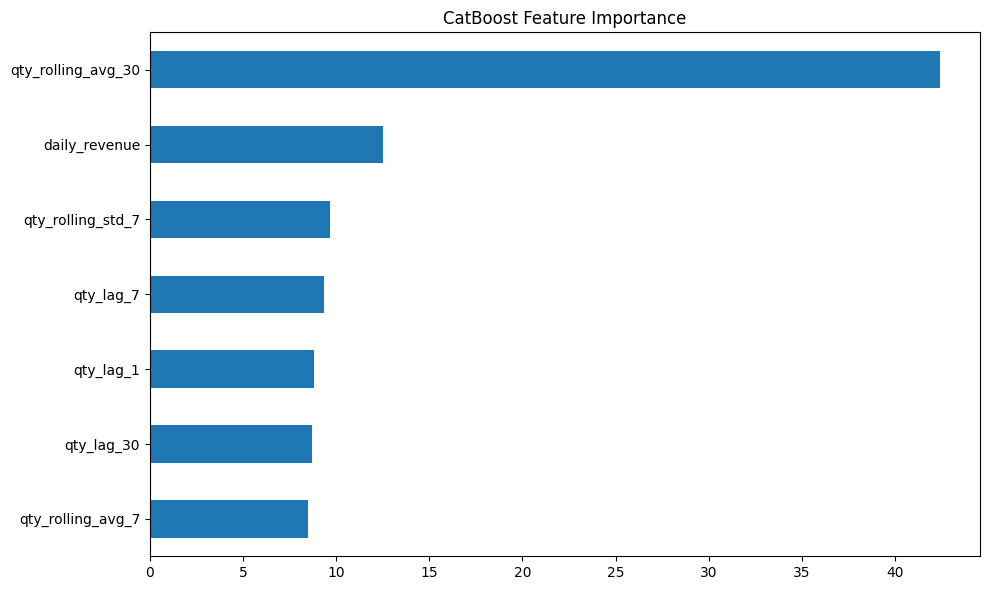

In [17]:
from catboost import CatBoostRegressor

with mlflow.start_run(run_name="catboost"):
    params = {
        "iterations":    300,
        "depth":         6,
        "learning_rate": 0.1,
        "random_seed":   42,
        "verbose":       False
    }
    model = CatBoostRegressor(**params)
    model.fit(X_train, y_train, eval_set=(X_test, y_test))
    metrics = evaluate_model(model, X_test, y_test, "CatBoost")

    mlflow.log_params(params)
    mlflow.log_param("model_type", "CatBoost")
    mlflow.log_metric("mae",  metrics["mae"])
    mlflow.log_metric("rmse", metrics["rmse"])
    mlflow.log_metric("r2",   metrics["r2"])
    mlflow.sklearn.log_model(model, "model")

    fig, ax = plt.subplots(figsize=(10, 6))
    feat_imp = pd.Series(
        model.get_feature_importance(),
        index=FEATURE_COLS
    ).sort_values()
    feat_imp.plot(kind="barh", ax=ax)
    ax.set_title("CatBoost Feature Importance")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")
    plt.show()

In [18]:
# Fetch all runs from MLflow
runs = mlflow.search_runs(
    experiment_names=["demand_forecasting"],
    filter_string="tags.mlflow.runName != 'test_run'"
)

# Keep only the latest run for each model name
runs = runs.sort_values("start_time", ascending=False)
runs = runs.drop_duplicates(subset=["tags.mlflow.runName"], keep="first")

# Show comparison table
comparison = runs[[
    "tags.mlflow.runName",
    "metrics.mae",
    "metrics.rmse",
    "metrics.r2"
]].rename(columns={
    "tags.mlflow.runName": "Model",
    "metrics.mae":         "MAE",
    "metrics.rmse":        "RMSE",
    "metrics.r2":          "R2"
})

comparison = comparison.sort_values("RMSE")
print("Model Comparison (sorted by RMSE):")
print(comparison.to_string(index=False))

Model Comparison (sorted by RMSE):
                     Model       MAE      RMSE       R2
                  catboost 21.179307 69.993012 0.108569
         linear_regression 21.168455 70.006323 0.108230
linear_regression_baseline 21.168455 70.006323 0.108230
          ridge_regression 21.168455 70.006323 0.108230
          lasso_regression 21.168719 70.006463 0.108227
                  lightgbm 21.294817 70.947276 0.084096
               lightgbm_v1 21.294817 70.947276 0.084096
         gradient_boosting 21.379369 73.331745 0.021497
             random_forest 21.506002 73.382860 0.020132
                   xgboost 21.571503 74.016277 0.003143
                xgboost_v1 21.571503 74.016277 0.003143


In [19]:
# Get the run with lowest RMSE
best_run      = runs.sort_values("metrics.rmse").iloc[0]
best_run_id   = best_run["run_id"]
best_run_name = best_run["tags.mlflow.runName"]

print(f"Best model: {best_run_name}")
print(f"Best RMSE:  {best_run['metrics.rmse']:.4f}")
print(f"Run ID:     {best_run_id}")

# Register in MLflow Model Registry
# This gives the model a versioned name you can reference later
model_uri = f"runs:/{best_run_id}/model"
result = mlflow.register_model(model_uri, "demand_forecast_model")

print(f"\nModel registered as version: {result.version}")

/Users/azeemkhalipha/anaconda3/envs/mlops/lib/python3.11/site-packages/mlflow/tracking/_model_registry/utils.py:220: FutureWarning: The filesystem model registry backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri)
Successfully registered model 'demand_forecast_model'.
2026/06/07 22:30:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 3f2c52aedfae4689aac9ac80a539cee2 has no artifacts at artifact path 'model', registering model based on models:/m-b9e793391037430286d232b593a594a7 instead


Best model: catboost
Best RMSE:  69.9930
Run ID:     3f2c52aedfae4689aac9ac80a539cee2

Model registered as version: 1


Created version '1' of model 'demand_forecast_model'.


In [20]:
import pickle

# Load the registered model
loaded_model = mlflow.pyfunc.load_model(
    f"models:/demand_forecast_model/1"
)

# Make sample predictions
sample      = X_test.head(5)
predictions = loaded_model.predict(sample)

results = pd.DataFrame({
    "actual":    y_test.head(5).values,
    "predicted": predictions.round(2)
})
results["error"] = (results["actual"] - results["predicted"]).abs().round(2)
print("Sample predictions:")
print(results.to_string(index=False))

# Save as pickle for the API to use
os.makedirs(f"{PROJECT_ROOT}/models", exist_ok=True)
with open(f"{PROJECT_ROOT}/models/demand_forecast_v1.pkl", "wb") as f:
    pickle.dump(loaded_model, f)

print(f"\nModel saved to: {PROJECT_ROOT}/models/demand_forecast_v1.pkl")

Sample predictions:
 actual  predicted  error
   12.0      20.59   8.59
  288.0      29.40 258.60
   19.0      25.84   6.84
    4.0       9.52   5.52
   12.0      12.17   0.17

Model saved to: /Users/azeemkhalipha/mlops-retail-platform/models/demand_forecast_v1.pkl
